fashion mnist - comparing a simple cnn vs resnet18 (transfer learning) against the old sklearn pipeline

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.cuda.get_device_name(0))
device

NVIDIA GeForce RTX 4070 Laptop GPU


'cuda'

In [6]:
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
len(classes)

10

## data

In [9]:
# totensor + normalize
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=tfm)
test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

print(len(train_data), len(test_data))

100.0%


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

60000 10000


Text(0.5, 1.0, 'Ankle boot')

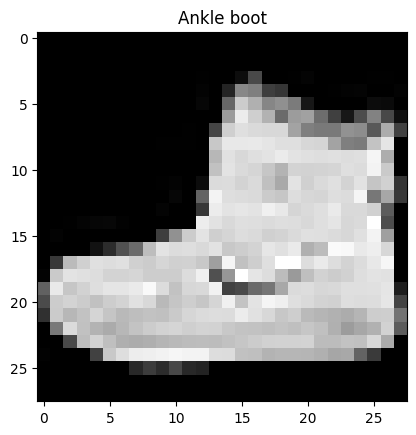

In [11]:
# quick sanity check that the data looks right
img, label = train_data[0]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(classes[label])

## model 1 - small cnn from scratch

In [14]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

In [16]:
model = CNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        opt.zero_grad()
        out = model(imgs)
        loss = loss_fn(out, labels)
        loss.backward()
        opt.step()

        total_loss += loss.item()

    print(f"epoch {epoch+1}, loss = {total_loss/len(train_loader):.4f}")

epoch 1, loss = 0.5070
epoch 2, loss = 0.3293
epoch 3, loss = 0.2814
epoch 4, loss = 0.2523
epoch 5, loss = 0.2259


In [28]:
model.eval()
preds = []
actual = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        out = model(imgs)
        p = out.argmax(1).cpu().numpy()
        preds.extend(p)
        actual.extend(labels.numpy())

cnn_acc = accuracy_score(actual, preds)
print("cnn test acc:", cnn_acc)
print(classification_report(actual, preds, target_names=classes))

cnn test acc: 0.9091
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.80      0.85      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.88      0.83      0.85      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.81      0.90      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.71      0.78      0.74      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



## model 2 - resnet18, pretrained

In [30]:
# resnet wants 3 channel + bigger images so different transform here
resnet_tfm = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data_r = datasets.FashionMNIST(root="./data", train=True, transform=resnet_tfm)
test_data_r = datasets.FashionMNIST(root="./data", train=False, transform=resnet_tfm)

train_loader_r = DataLoader(train_data_r, batch_size=64, shuffle=True, num_workers=2)
test_loader_r = DataLoader(test_data_r, batch_size=128, shuffle=False, num_workers=2)

In [34]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# freeze everything except last block + fc
for name, p in resnet.named_parameters():
    if "layer4" not in name and "fc" not in name:
        p.requires_grad = False

resnet.fc = nn.Linear(resnet.fc.in_features, 10)
resnet = resnet.to(device)

In [36]:
opt2 = torch.optim.Adam(resnet.parameters(), lr=1e-4)

epochs2 = 3
for epoch in range(epochs2):
    resnet.train()
    running_loss = 0
    for imgs, labels in train_loader_r:
        imgs, labels = imgs.to(device), labels.to(device)

        opt2.zero_grad()
        out = resnet(imgs)
        loss = loss_fn(out, labels)
        loss.backward()
        opt2.step()
        running_loss += loss.item()

    print(f"epoch {epoch+1}/{epochs2} loss {running_loss/len(train_loader_r):.4f}")

epoch 1/3 loss 0.2832
epoch 2/3 loss 0.1453
epoch 3/3 loss 0.0804


In [38]:
resnet.eval()
preds_r, actual_r = [], []

with torch.no_grad():
    for imgs, labels in test_loader_r:
        imgs = imgs.to(device)
        out = resnet(imgs)
        p = out.argmax(1).cpu().numpy()
        preds_r.extend(p)
        actual_r.extend(labels.numpy())

resnet_acc = accuracy_score(actual_r, preds_r)
print("resnet test acc:", resnet_acc)
print(classification_report(actual_r, preds_r, target_names=classes))

resnet test acc: 0.9173
              precision    recall  f1-score   support

 T-shirt/top       0.95      0.74      0.83      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.87      0.89      0.88      1000
       Dress       0.92      0.91      0.92      1000
        Coat       0.88      0.90      0.89      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.69      0.83      0.75      1000
     Sneaker       0.95      0.99      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



## comparing all 3

In [41]:
sklearn_acc = 0.907

print("sklearn baseline:", sklearn_acc)
print("simple cnn:", cnn_acc)
print("resnet18:", resnet_acc)

sklearn baseline: 0.907
simple cnn: 0.9091
resnet18: 0.9173


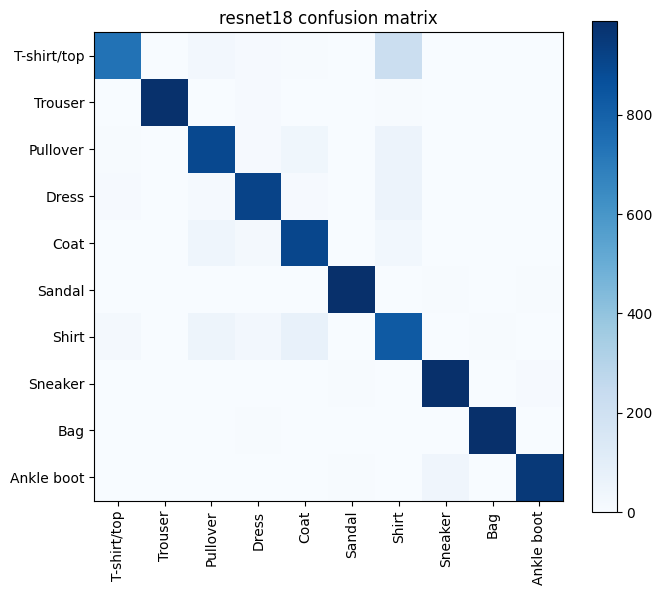

In [43]:
cm = confusion_matrix(actual_r, preds_r)

plt.figure(figsize=(7,6))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(10), classes, rotation=90)
plt.yticks(range(10), classes)
plt.colorbar()
plt.title("resnet18 confusion matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")

## grad-cam

just want to see what the model is actually looking at, not just trust the accuracy number

In [46]:
# hooking into the last conv block to grab activations + gradients
activations = None
gradients = None

def fwd_hook(module, inp, out):
    global activations
    activations = out.detach()

def bwd_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0].detach()

target_layer = resnet.layer4[-1]
target_layer.register_forward_hook(fwd_hook)
target_layer.register_full_backward_hook(bwd_hook)

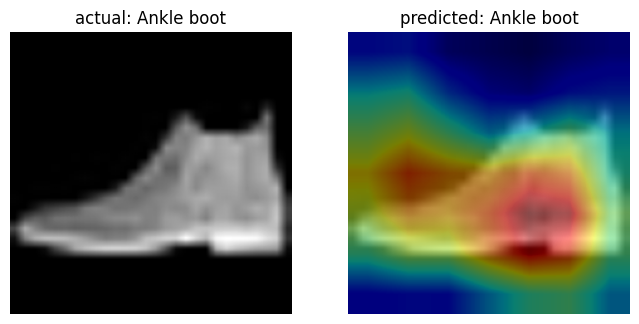

In [48]:
img, label = test_data_r[0]
x = img.unsqueeze(0).to(device)

resnet.eval()
out = resnet(x)
pred_class = out.argmax(1).item()

resnet.zero_grad()
out[0, pred_class].backward()

weights = gradients.mean(dim=(2,3), keepdim=True)
cam = (weights * activations).sum(1, keepdim=True)
cam = F.relu(cam)
cam = F.interpolate(cam, size=(224,224), mode="bilinear")
cam = cam.squeeze().cpu().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img[0], cmap="gray")
plt.title(f"actual: {classes[label]}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img[0], cmap="gray")
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.title(f"predicted: {classes[pred_class]}")
plt.axis("off")
plt.savefig("gradcam_example.png")

## save the model

In [51]:
# saving resnet since it should be the better one, swap if simple cnn actually wins
torch.save(resnet.state_dict(), "vision_resnet18.pt")
print("saved")

saved
